# ShowDiffraction

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/electronmicroscopy/quantem.widget/blob/main/docs/tutorials/showdiffraction.ipynb)

In [1]:
import numpy as np

from quantem.widget import ShowDiffraction

rng = np.random.default_rng(0)
size = 256
center = (size - 1) / 2
rows, cols = np.mgrid[0:size, 0:size]
radius = np.hypot(rows - center, cols - center)


def bragg_lattice(rotation_deg=0.0, spacing_px=28.0):
    angle = np.deg2rad(rotation_deg)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    pattern = np.zeros((size, size), np.float32)
    for h in range(-4, 5):
        for k in range(-4, 5):
            spot_row = center + (h * cos_a - k * sin_a) * spacing_px
            spot_col = center + (h * sin_a + k * cos_a) * spacing_px
            amplitude = 6.0 if h == 0 and k == 0 else 1.0 / (1 + 0.4 * (h * h + k * k))
            pattern += amplitude * np.exp(-((rows - spot_row) ** 2 + (cols - spot_col) ** 2) / 8.0)
    return pattern


single_crystal = bragg_lattice()
tilt_series = np.stack([bragg_lattice(angle) for angle in (0, 4, 8, 12)]).astype(np.float32)

ring_radii_px = (34.0, 55.0, 78.0, 96.0)
polycrystalline = 3.0 * np.exp(-(radius ** 2) / 32.0)
for ring_radius in ring_radii_px:
    polycrystalline += 2.0 * np.exp(-((radius - ring_radius) ** 2) / 9.68)
polycrystalline = (polycrystalline + 0.01 * rng.random((size, size))).astype(np.float32)

## Single-crystal SAED

In [2]:
saed = ShowDiffraction(
    single_crystal,
    center=(center, center),
    bf_radius=14,
    k_pixel_size=0.018,
    title="Single-crystal SAED",
    
    verbose=False,
    panel_width_px=530,
)
saed.detect_spots(max_spots=12)
saed

ShowDiffraction(shape=(1, 256, 256), sampling=(1.0 Å, 0.018 1/Å), frame=0/1, spots=12, title='Single-crystal SAED')

## Polycrystalline rings

In [3]:
powder = ShowDiffraction(polycrystalline, title="Polycrystalline", verbose=False, panel_width_px=530)
powder.detect_rings(max_rings=4)
powder.calibrate_from_ring(powder.rings[0]["radius_px"], d_known=2.355)
powder

ShowDiffraction(shape=(1, 256, 256), sampling=(1.0 Å, 0.012631480808671821 1/Å), frame=0/1, title='Polycrystalline')

## Tilt series

In [4]:
tilt = ShowDiffraction(
    tilt_series,
    center=(center, center),
    bf_radius=14,
    k_pixel_size=0.018,
    title="Tilt series",
    
    verbose=False,
    panel_width_px=530,
)
tilt

ShowDiffraction(shape=(4, 256, 256), sampling=(1.0 Å, 0.018 1/Å), frame=0/4, title='Tilt series')

## Magnetite-like rings

Generate a magnetite-style ring pattern in the notebook so the tutorial stays self-contained.

In [5]:
# Synthetic magnetite-like SAED pattern: central beam + Debye-Scherrer rings.
size_m = 512
center_m = (size_m - 1) / 2
m_rows, m_cols = np.mgrid[0:size_m, 0:size_m]
m_radius = np.hypot(m_rows - center_m, m_cols - center_m)
magnetite_pattern = 4.0 * np.exp(-(m_radius ** 2) / 80.0)
for ring_radius, strength, width in [
    (70.0, 1.7, 6.0),
    (113.0, 1.3, 7.0),
    (140.0, 1.0, 8.0),
    (184.0, 0.8, 9.0),
    (226.0, 0.55, 10.0),
]:
    magnetite_pattern += strength * np.exp(-((m_radius - ring_radius) ** 2) / (2 * width ** 2))
magnetite_pattern += 0.035 * rng.random((size_m, size_m))
magnetite_pattern = magnetite_pattern.astype(np.float32)

In [6]:
magnetite = ShowDiffraction(magnetite_pattern, title="Magnetite-like rings", verbose=False, panel_width_px=530)
magnetite.auto_detect_center()
magnetite.detect_rings(max_rings=5, exclude_radius=40)
inner_ring = min(magnetite.rings, key=lambda ring: ring["radius_px"])
magnetite.calibrate_from_ring(inner_ring["radius_px"], d_known=2.532)
magnetite.dp_colormap = "viridis"
magnetite

ShowDiffraction(shape=(1, 512, 512), sampling=(1.0 Å, 0.005672910439341243 1/Å), frame=0/1, title='Magnetite-like rings')

### Save the analysis

In [7]:
magnetite.summary()
magnetite.save("magnetite_state.json")

ShowDiffraction.measurements_from_state("magnetite_state.json")[:2]

Magnetite-like rings
════════════════════════════════
Frames:   1 (showing #0)
Detector: 512×512 (0.0057 1/Å/px)
Calib:    from_ring (d=2.532 Å @ r=69.6 px)
Center:   (255.5, 255.6)  BF r=11.9 px
Spots:    0
Rings:    5
Display:  viridis | log


[{'id': 1,
  'kind': 'ring',
  'raw_row': None,
  'raw_col': None,
  'row': None,
  'col': None,
  'row_err': None,
  'col_err': None,
  'r_pixels': 69.61941528320312,
  'r_pixels_err': None,
  'g_inv_angstrom': 0.3949447077409163,
  'g_inv_angstrom_err': None,
  'd_angstrom': 2.532,
  'd_angstrom_err': None,
  'angle_deg': None,
  'angle_deg_err': None,
  'intensity': 1.7121703624725342,
  'fit_quality': None,
  'hkl': '',
  'note': ''},
 {'id': 2,
  'kind': 'ring',
  'raw_row': None,
  'raw_col': None,
  'row': None,
  'col': None,
  'row_err': None,
  'col_err': None,
  'r_pixels': 112.69329833984375,
  'r_pixels_err': None,
  'g_inv_angstrom': 0.6392989885958967,
  'g_inv_angstrom_err': None,
  'd_angstrom': 1.5642133302859074,
  'd_angstrom_err': None,
  'angle_deg': None,
  'angle_deg_err': None,
  'intensity': 1.317672848701477,
  'fit_quality': None,
  'hkl': '',
  'note': ''}]

In [8]:
# Optional
export_path = saed.export_html("showdiffraction_saed.html", title="Single-crystal SAED")
export_path.name

'showdiffraction_saed.html'

## SSB phase FFT

FFT of an SSB reconstructed phase for three probe-origin choices: raw, initial
`r0`, and refined `r*`. The three frames stack into one viewer with a frame
slider, and spots persist across frames, so picks made on the `r*` frame stay
overlaid while scrubbing back to `raw` and `r0`. The patterns are uncalibrated,
so radii stay in pixels; linear scaling because the frames are already
gamma-compressed.

In [9]:
from PIL import Image

def load_gray(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)

base = "showdiffraction_data/fig6_ssb_{}_phaseFFT_gamma0p7.jpg"
raw, r0, r_star = (load_gray(base.format(name)) for name in ("raw", "r0", "r_star"))

ssb = ShowDiffraction(
    np.stack([raw, r0, r_star]),
    center=(388, 388),
    dp_scale_mode="linear",
    title="SSB phase FFT: raw / r0 / r*",
    verbose=False,
    panel_width_px=530,
)
ssb.frame_idx = 2
ssb.detect_spots(max_spots=12)
ssb

ShowDiffraction(shape=(3, 776, 776), sampling=(1.0 Å, 0.0 px), frame=2/3, spots=12, title='SSB phase FFT: raw / r0 / r*')

In [10]:
ssb.summary()

SSB phase FFT: raw / r0 / r*
════════════════════════════════
Frames:   3 (showing #2)
Detector: 776×776 (uncalibrated px/px)
Center:   (388.0, 388.0)  BF r=97.0 px
Spots:    12
  #1 (633.1, 270.9) d=271.6 px  ∠=0.0°
  #2 (143.9, 506.1) d=271.1 px  ∠=179.7°
  #3 (553.0, 324.4) d=176.8 px  ∠=4.5°
  #4 (224.0, 452.6) d=176.2 px  ∠=176.0°
  #5 (273.9, 223.7) d=200.0 px  ∠=99.2°
  ... +7 more
Rings:    0
Display:  inferno | linear


## Bragg disk detection

`BraggVectors` cross-correlates a template against every pattern in a 4D-STEM
scan. The detections accumulate into a Bragg vector map, which is itself a
diffraction pattern and drops straight into the viewer.

The scan below is a Si/SiGe nanobeam diffraction measurement (a cropped region
of the `Si_SiGe_exp` sample dataset distributed with py4DSTEM). Nanobeam keeps
the convergence angle small enough that the Bragg disks stay separated, which
is what makes them individually detectable.

In [11]:
from quantem.core.datastructures import Dataset4dstem
from quantem.diffraction import BraggVectors

with np.load("showdiffraction_data/sisige_nbed.npz") as handle:
    scan = handle["dp"].astype(np.float32)

dataset = Dataset4dstem.from_array(scan, name="Si/SiGe nanobeam")
dataset.shape

(25, 32, 64, 64)

In [12]:
disk_radius = 4.5

bragg = BraggVectors.from_dataset(dataset)
bragg.make_template_synthetic(radius=disk_radius)
bragg.detect_disks(min_spacing=8.0, max_num_peaks=13, progressbar=False)

bvm = bragg.compute_bvm()
bvm.array.shape

(64, 64)

In [13]:
det_center = scan.shape[-1] // 2
bvm_view = ShowDiffraction(
    bvm.array.astype(np.float32),
    center=(det_center, det_center),
    bf_radius=8,
    title="Bragg vector map",
    verbose=False,
    panel_width_px=530,
)
# sparse histogram, so a lower prominence threshold than a raw pattern needs
bvm_view.detect_spots(max_spots=12, threshold_rel=0.08)
bvm_view

ShowDiffraction(shape=(1, 64, 64), sampling=(1.0 Å, 0.0 px), frame=0/1, spots=6, title='Bragg vector map')

### Strain map

Fitting the lattice at every scan position turns the detections into strain.
The reference lattice is taken from the Si on either side, so the SiGe layer
reads as the strained region.

`rotation_angle_deg` rotates the tensor out of the detector frame: 68 degrees
is where the shear is smallest, which lines the normal components up with the
principal strain axes.

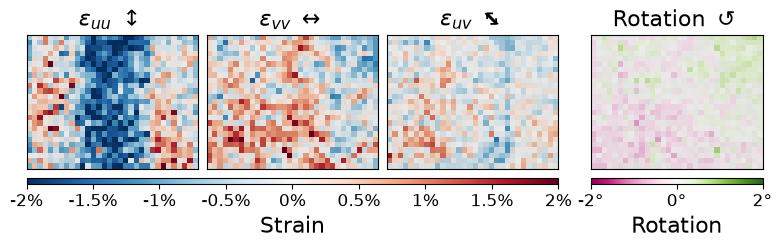

In [14]:
bragg.choose_basis_vectors(plot=False)
bragg.index_peaks(plot=False)
bragg.fit_lattice(plot=False, progressbar=False)

# Si sits on both sides of the SiGe band, so reference the lattice to it
si_reference = np.ones(scan.shape[:2])
si_reference[:, 10:23] = 0.0

strain = bragg.calculate_strain_map()
strain.update_reference(strain_mask=si_reference)
strain.plot_strain(rotation_angle_deg=68, strain_range_percent=(-2.0, 2.0));

### Template matching on the SSB phase FFT

The same detector runs on a single pattern, so it also works on the reconstructed
phase FFT from earlier. The saturated center is masked out first, leaving the
lattice spots for the viewer to measure.

In [15]:
import torch

from quantem.diffraction.disk_detection import (
    detect_disks,
    make_template,
    synthetic_probe,
    template_fourier,
)

ssb_center = 388
ssb_rows, ssb_cols = np.mgrid[0:r_star.shape[0], 0:r_star.shape[1]]
ssb_radius = np.hypot(ssb_rows - ssb_center, ssb_cols - ssb_center)

# the saturated central blob outshines the spots, so drop it before matching
masked = np.where(ssb_radius < 140, 0.0, r_star).astype(np.float32)

probe = synthetic_probe(r_star.shape, 3.0, edge=1.0, center=(ssb_center, ssb_center))
template_ft = template_fourier(
    make_template(probe, center=(ssb_center, ssb_center), subtract_mean=True)
)
ssb_peaks = detect_disks(torch.as_tensor(masked), template_ft, min_spacing=12.0, max_num_peaks=10)

np.round(ssb_peaks, 1)

array([[230.6, 318. , 217.7],
       [546.4, 459. , 217.7],
       [244.2, 494.2, 211.8],
       [532.8, 282.8, 211.4],
       [256.4, 276.8, 209.5],
       [520.6, 500.2, 209.4],
       [402.6, 564.9, 201.1],
       [374.4, 212.1, 200.8],
       [224. , 452.5, 153.3],
       [553. , 324.5, 153.3]])

In [16]:
matched = ShowDiffraction(
    r_star,
    center=(ssb_center, ssb_center),
    dp_scale_mode="linear",
    title="Template-matched spots",
    verbose=False,
    panel_width_px=530,
)
for peak_row, peak_col, _ in ssb_peaks:
    matched.add_spot(peak_row, peak_col)

matched

ShowDiffraction(shape=(1, 776, 776), sampling=(1.0 Å, 0.0 px), frame=0/1, spots=10, title='Template-matched spots')

## Denoise

`denoise` filters whatever frame the viewer is holding, so what it acts on is
whatever you passed in. Two different things appear in this notebook:

- a **diffraction pattern** from the Si/SiGe scan -- one detector readout, the
  thing ShowDiffraction is normally pointed at
- the **SSB phase FFT**, which is not a diffraction pattern at all: it is the
  Fourier transform of a reconstructed real-space phase

Both are 2D images with sharp features on a noisy background, so the same
solvers apply. It is a view stage either way: spots, rings and every export keep
reading the raw frame, so a measurement never depends on a display knob.

The methods are denova's solvers, which pick their own regularization strength
from the noise model rather than taking a width parameter.


### On a diffraction pattern

A single readout from the Si/SiGe scan. Shot noise between the disks goes; the
disk edges the d-spacing measurement depends on stay put.


In [ ]:
single_dp = scan[6, 16]

ShowDiffraction(
    single_dp,
    center=(det_center, det_center),
    denoise="denova_tv",
    title="Diffraction pattern",
    verbose=False,
    panel_width_px=530,
)


### Comparing methods

denova's four 2D solvers on the same pattern. TV is piecewise constant and keeps
the sharpest edges; TV2 favours smooth ramps; TV1-2 mixes the two; Tikhonov
smooths everywhere.


In [ ]:
import matplotlib.pyplot as plt

from quantem.widget.utils.display_filter import apply_display_filter

methods = ["denova_tv", "denova_tv2", "denova_tv12", "denova_tikhonov"]

fig, axes = plt.subplots(1, len(methods) + 1, figsize=(15, 3.2))
axes[0].imshow(np.log1p(single_dp), cmap="inferno")
axes[0].set_title("raw")

for ax, mode in zip(axes[1:], methods):
    view = apply_display_filter(single_dp, mode=mode)
    ax.imshow(np.log1p(np.clip(view, 0, None)), cmap="inferno")
    ax.set_title(mode.replace("denova_", ""), fontsize=9)

for ax in axes:
    ax.axis("off")
plt.tight_layout();


### Across denoise strength

The solver converges within about eight iterations, so stepping the iteration
count barely changes the picture. What does change it is the regularization
strength: denova calibrates lambda to chi-squared = 1, which denoises exactly to
the noise level and is deliberately conservative. Sweeping lambda around that
point shows the useful range, from under-smoothed to firmly denoised, and the
frame slider scrubs it. The sweep stops at 5x: beyond about 6x the flat-patch
fraction climbs and the result looks posterized rather than denoised.

Written out as an MP4 as well.


In [ ]:
from matplotlib import colormaps
from PIL import Image

from denova import denoise
from quantem.widget import movie

calibrated = denoise(r_star, method="tv")
print(f"auto lambda {calibrated.lam:.3g}, chi2 {calibrated.chi2:.3g}")

# geometric sweep around the calibrated value: under-smoothed to over-smoothed
# past roughly 6x auto the result starts reading as posterized, not denoised
lambdas = calibrated.lam * np.geomspace(0.4, 5.0, 39)
progression = np.empty((len(lambdas) + 1, *r_star.shape), np.float32)
progression[0] = r_star
for i, lam in enumerate(lambdas, start=1):
    progression[i] = np.asarray(denoise(r_star, method="tv", lam=float(lam)).output, np.float32)

# one contrast for the whole stack, so brightness changes mean denoising and not
# per-frame rescaling. Colormap frame by frame: RGBA over the whole stack at
# once would be an order of magnitude larger than the stack itself.
lo, hi = float(progression.min()), float(np.percentile(progression, 99.5))
cmap = colormaps["inferno"]
frames = [
    Image.fromarray((cmap(np.clip((f - lo) / (hi - lo), 0, 1))[..., :3] * 255).astype(np.uint8))
    for f in progression
]

movie.save_mp4(frames, "denova_tv_strength_sweep.mp4", fps=8)


In [ ]:
ShowDiffraction(
    progression,
    dp_scale_mode="linear",
    title="denova TV: increasing strength",
    verbose=False,
    panel_width_px=530,
)
